# **Libraries**

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## Visualize Sample Images

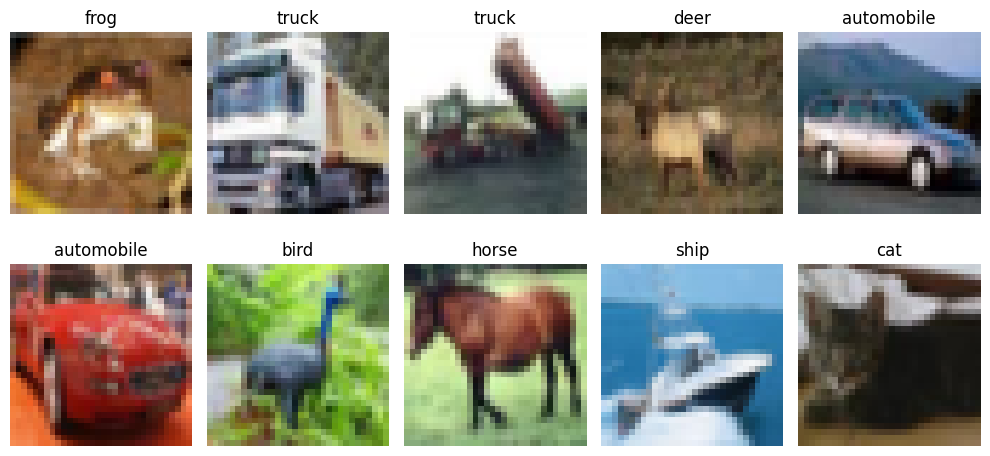

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# Preprocessing


In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 1. ANN Model


In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.2684 - loss: 1.9956 - val_accuracy: 0.3220 - val_loss: 1.9130
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3133 - loss: 1.8722 - val_accuracy: 0.3672 - val_loss: 1.7847
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3325 - loss: 1.8274 - val_accuracy: 0.3740 - val_loss: 1.7496
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3485 - loss: 1.7857 - val_accuracy: 0.3930 - val_loss: 1.7175
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3631 - loss: 1.7543 - val_accuracy: 0.3748 - val_loss: 1.7129
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3654 - loss: 1.7477 - val_accuracy: 0.4030 - val_loss: 1.6822
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3754 - loss: 1.7230 - val_accuracy: 0.3810 - val_loss: 1.6971
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3804 - loss: 1.7089 - val_accuracy: 0.

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4188 - loss: 1.6534
ANN Test Accuracy: 0.4187999963760376


# 2. CNN Model

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4602 - loss: 1.5025 - val_accuracy: 0.4946 - val_loss: 1.3824
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6058 - loss: 1.1316 - val_accuracy: 0.6006 - val_loss: 1.1761
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6683 - loss: 0.9500 - val_accuracy: 0.6104 - val_loss: 1.1682
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7135 - loss: 0.8246 - val_accuracy: 0.5778 - val_loss: 1.3003
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7485 - loss: 0.7249 - val_accuracy: 0.6648 - val_loss: 0.9811
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7711 - loss: 0.6544 - val_accuracy: 0.7082 - val_loss: 0.8905
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7947 - loss: 0.5793 - val_accuracy: 0.7188 - val_loss: 0.8807
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8167 - loss: 0.5208 - val_accuracy: 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6752 - loss: 1.2262
CNN Test Accuracy: 0.6751999855041504


## 3. Compare Learning Curves

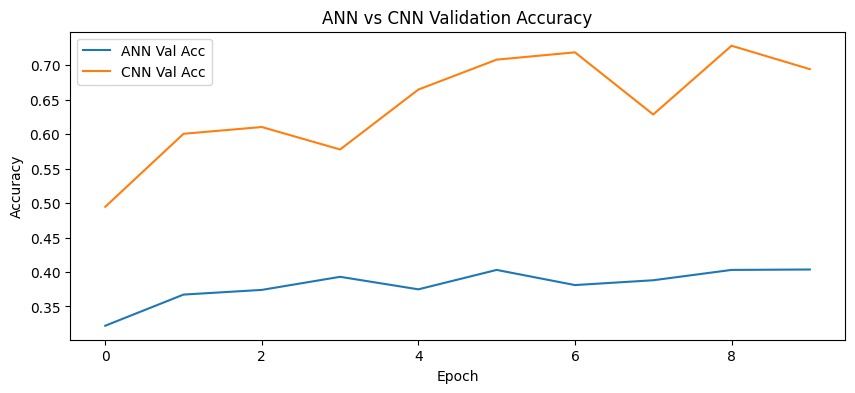

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

#4. Training Strategy Upgrade: Data Augmentation

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.3665 - loss: 1.7323 - val_accuracy: 0.5014 - val_loss: 1.3699
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4705 - loss: 1.4782 - val_accuracy: 0.5622 - val_loss: 1.2078
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5122 - loss: 1.3727 - val_accuracy: 0.5808 - val_loss: 1.1853
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5337 - loss: 1.3175 - val_accuracy: 0.6014 - val_loss: 1.1443
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5497 - loss: 1.2758 - val_accuracy: 0.6292 - val_loss: 1.0787
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5641 - loss: 1.2396 - val_accuracy: 0.5988 - val_loss: 1.1430
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5728 - loss: 1.2105 - val_accuracy: 0.6494 - val_loss: 1.0011
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5818 - loss: 1

In [11]:
aug_cnn_test_loss, aug_cnn_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("AUG CNN Test Accuracy:", aug_cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6250 - loss: 1.0664
AUG CNN Test Accuracy: 0.625


#5. Comparison Table

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN","Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4188
1,CNN,0.6752
2,Augmented CNN,0.6250


# TASKS

# Task:1 Increase ANN layers and observe performance

In [13]:
deep_ann_model = models.Sequential([
    layers.Input(shape=(3072,)),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu'),

    layers.Dense(10, activation='softmax')
])

deep_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_ann_history = deep_ann_model.fit(
    x_train_flat,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

deep_ann_test_loss, deep_ann_test_acc = deep_ann_model.evaluate(
    x_test_flat,
    y_test,
    verbose=0
)

print(f"Baseline ANN Accuracy: {ann_test_acc:.4f}")
print(f"Deep ANN Accuracy: {deep_ann_test_acc:.4f}")
print(f"Difference: {(deep_ann_test_acc - ann_test_acc)*100:+.2f}%")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.1699 - loss: 2.1695 - val_accuracy: 0.2324 - val_loss: 2.0260
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2102 - loss: 2.0442 - val_accuracy: 0.2536 - val_loss: 1.9675
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2204 - loss: 2.0162 - val_accuracy: 0.2406 - val_loss: 1.9740
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2363 - loss: 1.9944 - val_accuracy: 0.2480 - val_loss: 1.9685
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2513 - loss: 1.9727 - val_accuracy: 0.2702 - val_loss: 1.9744
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2557 - loss: 1.9611 - val_accuracy: 0.3006 - val_loss: 1.9597
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2609 - loss: 1.9540 - val_accuracy: 0.2740 - val_loss: 1.9887
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2639 - loss: 1.9472 - val_accuracy: 0

**Task 1**
- Added more Dense layers
- Marginal accuracy gain but still model is not performing well compare to cnn and compare to preious ann this one performed too poorly.

#Task:2 Change CNN filters from 32→64→128

In [14]:
cnn_filter_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])


cnn_filter_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_filter_history = cnn_filter_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

cnn_filter_test_loss, cnn_filter_test_acc = cnn_filter_model.evaluate(x_test_norm, y_test, verbose=0)

print(f"cnn Test Acc: {cnn_filter_test_acc:.2f}  ({cnn_filter_test_acc*100:.2f}%)")
print(f"Difference: {(cnn_filter_test_acc - cnn_test_acc)*100:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4841 - loss: 1.5230 - val_accuracy: 0.5528 - val_loss: 1.2939
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6263 - loss: 1.0617 - val_accuracy: 0.5156 - val_loss: 1.3579
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6866 - loss: 0.8930 - val_accuracy: 0.6432 - val_loss: 1.0337
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7220 - loss: 0.7904 - val_accuracy: 0.6572 - val_loss: 1.0210
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7498 - loss: 0.7072 - val_accuracy: 0.6618 - val_loss: 1.0316
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7783 - loss: 0.6261 - val_accuracy: 0.6470 - val_loss: 1.1298
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7980 - loss: 0.5669 - val_accuracy: 0.7064 - val_loss: 0.8798
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8223 - loss: 0.5019 - val_accuracy: 

**Task 2**
- No changes as this model was already given in the file
- worked well it gave the 72% accuracy

# Task:3 Increase epochs to 20

In [15]:
Epoch20_cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])


Epoch20_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_Epoch_history = Epoch20_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

cnn_Epoch_test_loss, cnn_Epoch_test_acc = Epoch20_cnn_model.evaluate(x_test_norm, y_test, verbose=0)

print(f"Epoch 20 cnn Test Acc: {cnn_Epoch_test_acc:.2f}  ({cnn_Epoch_test_acc*100:.2f}%)")
print(f"Difference: {(cnn_Epoch_test_acc - cnn_test_acc)*100:.2f}")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4731 - loss: 1.5731 - val_accuracy: 0.5348 - val_loss: 1.3185
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6188 - loss: 1.0929 - val_accuracy: 0.6290 - val_loss: 1.0498
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6740 - loss: 0.9341 - val_accuracy: 0.6432 - val_loss: 1.0291
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7118 - loss: 0.8180 - val_accuracy: 0.6980 - val_loss: 0.8857
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7438 - loss: 0.7289 - val_accuracy: 0.6144 - val_loss: 1.1876
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7685 - loss: 0.6565 - val_accuracy: 0.7008 - val_loss: 0.8639
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7898 - loss: 0.5944 - val_accuracy: 0.6950 - val_loss: 0.9796
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8108 - loss: 0.5355 - val_accuracy: 

**Task 3**
- 20 Epochs
- Val_loss and val_accuracy is fluctuating too much after 6 epoch which can be interpret as there might be overfitting case after that

# Task:4 Add EarlyStopping

In [16]:
cnn_early_stopping_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_early_stopping_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

cnn_early_history = cnn_early_stopping_model.fit(
    x_train_norm, y_train,
    epochs=20,               # <- Task 3: 20 epochs maximum
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],  # <- Task 4: EarlyStopping
    verbose=1
)

early_cnn_test_loss, early_cnn_test_acc = cnn_early_stopping_model.evaluate(x_test_norm, y_test, verbose=0)

print(f"CNN + EarlyStopping Test Acc: {early_cnn_test_acc:.2f} ({early_cnn_test_acc*100:.2f}%)")
print(f"CNN Baseline Test Accuracy: {cnn_test_acc:.2f} ({cnn_test_acc*100:.2f}%)")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4749 - loss: 1.5583 - val_accuracy: 0.5194 - val_loss: 1.3442
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6230 - loss: 1.0703 - val_accuracy: 0.6306 - val_loss: 1.0541
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6829 - loss: 0.9018 - val_accuracy: 0.6764 - val_loss: 0.9476
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7263 - loss: 0.7853 - val_accuracy: 0.6386 - val_loss: 1.0441
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7531 - loss: 0.6992 - val_accuracy: 0.6860 - val_loss: 0.9270
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7813 - loss: 0.6235 - val_accuracy: 0.7120 - val_loss: 0.8753
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8031 - loss: 0.5633 - val_accuracy: 0.7120 - val_loss: 0.8527
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8189 - loss: 0.5066 - val_accuracy: 

**Task 4**
- EarlyStopping + 20-epoch
- This one worked better than task 3 because in task 3 there was a chances of overfitting in this we used EarlyStopping which avoids overfitting

# Task:5 Add data augmentation training

In [17]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])
aug_full_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_full_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_aug = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

aug_full_history = aug_full_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug],
    verbose=1
)

aug_full_test_loss, aug_full_test_acc = aug_full_model.evaluate(x_test_norm, y_test, verbose=0)
print("accuracy: ",aug_full_test_acc)
print(f"Improvement over CNN: +{(aug_full_test_acc - cnn_test_acc)*100:.2f} percentage points")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4063 - loss: 1.7299 - val_accuracy: 0.5110 - val_loss: 1.3720
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5174 - loss: 1.3596 - val_accuracy: 0.5238 - val_loss: 1.3494
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5645 - loss: 1.2384 - val_accuracy: 0.5868 - val_loss: 1.1704
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5932 - loss: 1.1590 - val_accuracy: 0.6446 - val_loss: 1.0155
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6152 - loss: 1.0980 - val_accuracy: 0.6434 - val_loss: 1.0231
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6338 - loss: 1.0470 - val_accuracy: 0.6154 - val_loss: 1.0881
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6513 - loss: 1.0052 - val_accuracy: 0.6224 - val_loss: 1.1323
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6579 - loss: 0.9810 - val_ac

**Task 5**
- CNN + 20 Epoch + Early Stopping + Data augmentation
- This one worked best amoung all the models with 2.62% more accuracy than the normal CNN results in test

## Conclusion
- Full Augmented CNN + EarlyStopping Task-5 — best generalised model
- Then CNN + 20 Epochs + EarlyStopping (Task 4) is the 2nd best model
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**